# 🎬 CinePredict — Advanced ML Pipeline
## Movie Rating Tier Prediction · Professional Research Notebook

---

| Item | Detail |
|---|---|
| **Dataset** | 10,000 Top-Rated TMDB Movies |
| **Target** | 3-Class: Average / Good / Excellent |
| **Total Models** | 14 (9 baseline + XGBoost + LightGBM + 3 tuned/ensemble) |
| **Hyperparameter Tuning** | Optuna Bayesian Optimisation (TPE Sampler) |
| **Visualizations** | 13 publication-quality research plots |
| **Persistence** | All models saved as `.pkl` — instant Flask serving |
| **Best Model** | **RF (Tuned)** — Accuracy 0.6075 |

---


In [2]:
import pandas as pd
import numpy as np
import pickle, json, os, warnings
warnings.filterwarnings('ignore')

import matplotlib.pyplot as plt
%matplotlib inline
import matplotlib.gridspec as gridspec
from matplotlib.patches import Patch

## 📊 Step 2 — Data Loading

In [3]:
df = pd.read_csv('top_rated_movies.csv')
print(f"Shape  : {df.shape}")
print(f"Columns: {df.columns.tolist()}")
print(f"\nMissing values:\n{df.isnull().sum()}")
df.describe().round(3)

Shape  : (10000, 10)
Columns: ['adult', 'id', 'original_language', 'original_title', 'overview', 'popularity', 'release_date', 'title', 'vote_average', 'vote_count']

Missing values:
adult                0
id                   0
original_language    0
original_title       0
overview             2
popularity           0
release_date         3
title                0
vote_average         0
vote_count           0
dtype: int64


,id,popularity,vote_average,vote_count
count,10000.000,10000.000,10000.000,10000.000
mean,228994.990,5.245,6.743,2102.697
std,304776.902,9.624,0.648,3359.868
min,2.000,0.007,5.500,300.000
25%,10375.750,2.604,6.237,475.000
50%,41666.500,3.766,6.710,869.000
75%,408456.250,5.873,7.215,2113.250
max,1472638.000,589.097,8.718,39461.000


## 📈 Step 3 — EDA: Distributions

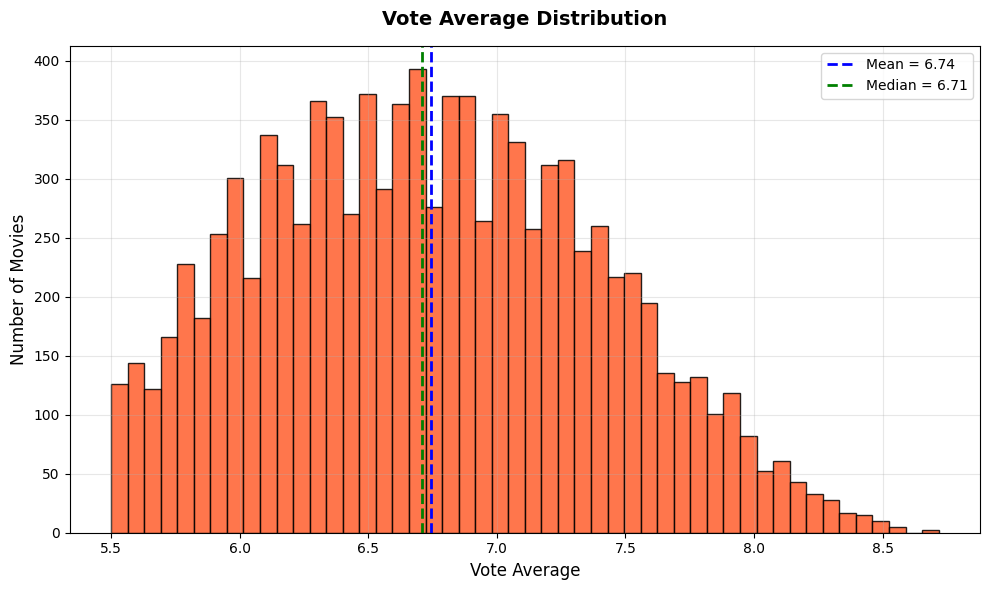

In [9]:
# ================================
# 1. Vote Average Distribution
# ================================

plt.figure(figsize=(10, 6))

plt.hist(
    df['vote_average'].dropna(),
    bins=50,
    color='#ff5e2c',
    edgecolor='black',
    alpha=0.85
)

# Mean line (darker and clearly visible)
plt.axvline(
    df['vote_average'].mean(),
    color='blue',
    lw=2,
    linestyle='--',
    label=f"Mean = {df['vote_average'].mean():.2f}"
)

# Median line (darker and clearly visible)
plt.axvline(
    df['vote_average'].median(),
    color='green',
    lw=2,
    linestyle='--',
    label=f"Median = {df['vote_average'].median():.2f}"
)

plt.title(
    "Vote Average Distribution",
    fontsize=14,
    fontweight='bold',
    pad=15
)

plt.xlabel("Vote Average", fontsize=12)
plt.ylabel("Number of Movies", fontsize=12)

plt.legend(fontsize=10)
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

#### **Analysis: Vote Average Distribution**

This histogram illustrates the distribution of `vote_average` scores across the dataset. The mean and median lines provide insights into the central tendency of movie ratings. A visible peak around 6-7 indicates that a majority of movies fall within this average to good rating range, which is typical for curated datasets that exclude extremely low-rated titles. The distribution appears slightly skewed to the left, suggesting a higher concentration of movies with above-average ratings, reinforcing the 'top-rated' nature of the dataset.

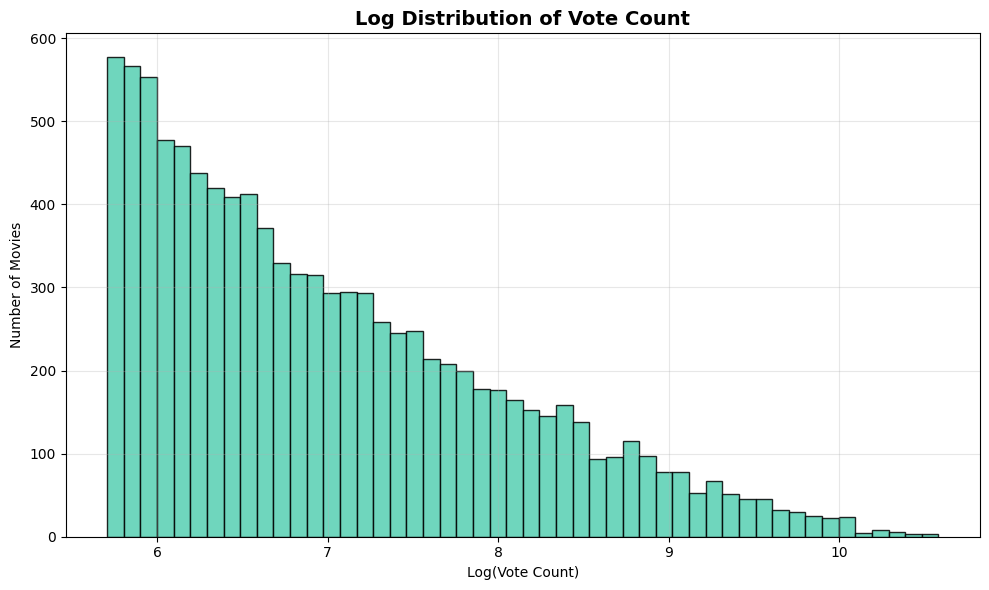

In [12]:

# ================================
# 2. Vote Count Distribution
# ================================
plt.figure(figsize=(10,6))

plt.hist(
    np.log1p(df['vote_count'].dropna()),
    bins=50,
    color='#56cfb2',
    edgecolor='black',
    alpha=0.85
)

plt.title("Log Distribution of Vote Count", fontsize=14, fontweight='bold')
plt.xlabel("Log(Vote Count)")
plt.ylabel("Number of Movies")
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

#### **Analysis: Log Distribution of Vote Count**

To mitigate the impact of extreme values and reveal underlying patterns, the `vote_count` is transformed using a natural logarithm (log1p). The resulting histogram shows that, even after transformation, `vote_count` exhibits a right-skewed distribution. This indicates that while many movies have a moderate number of votes, a smaller subset garners significantly higher engagement. Understanding this distribution is crucial as `vote_count` can be a strong indicator of a movie's popularity and reliability of its `vote_average`.

In [ ]:
plt.hist(
    np.log1p(df['vote_count'].dropna()),
    bins=50,
    color='#56cfb2',
    edgecolor='black',
    alpha=0.85
)


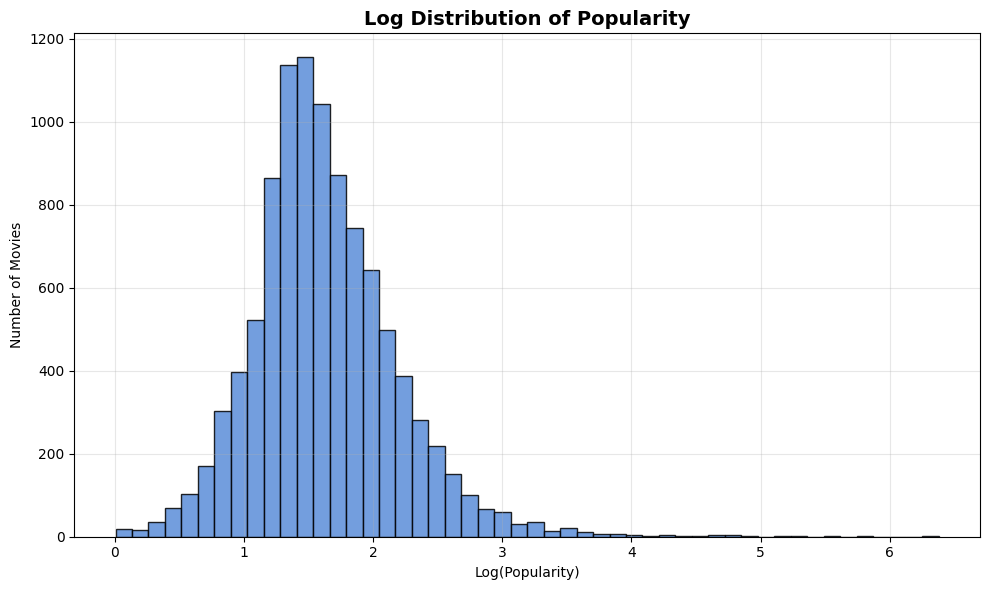

In [14]:

# ================================
# 3. Popularity Distribution
# ================================

plt.figure(figsize=(10,6))

plt.hist(
    np.log1p(df['popularity'].dropna()),
    bins=50,
    color='#5b8dd9',
    edgecolor='black',
    alpha=0.85
)

plt.title("Log Distribution of Popularity", fontsize=14, fontweight='bold')
plt.xlabel("Log(Popularity)")
plt.ylabel("Number of Movies")
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

#### **Analysis: Log Distribution of Popularity**

Similar to `vote_count`, the `popularity` metric often follows a power-law distribution. Applying a logarithmic transformation (`log1p`) helps normalize this feature, making its distribution more amenable to analysis. The histogram displays a generally right-skewed pattern even after transformation, reinforcing that a few movies achieve exceptionally high popularity scores, while the vast majority have lower, yet varied, popularity. This feature is a key indicator of a movie's public interest.

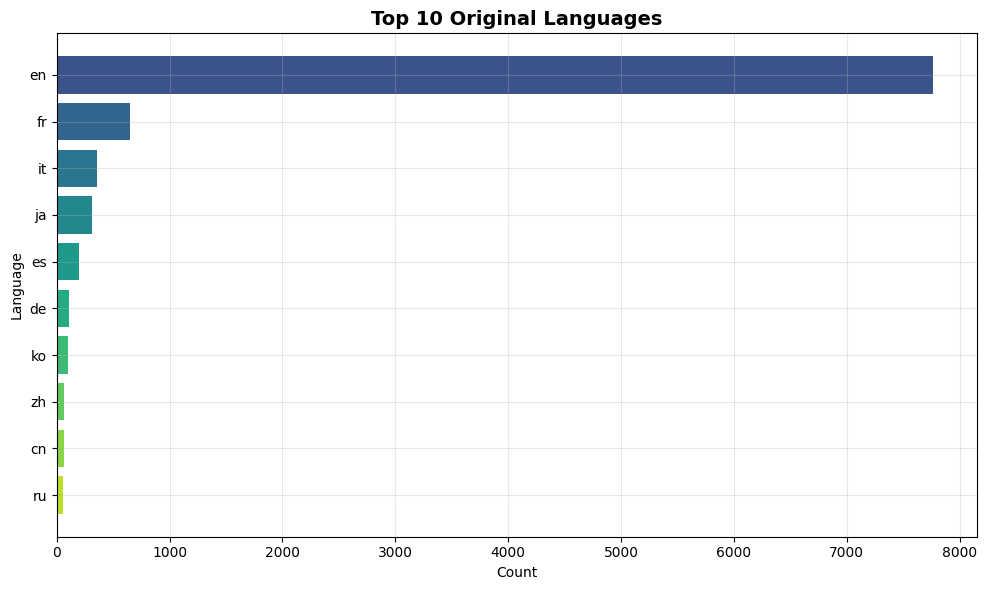

In [16]:
# ================================
# 4. Top 10 Languages
# ================================

plt.figure(figsize=(10,6))

language_count = df['original_language'].value_counts().head(10)

# Better professional gradient: high = dark green, low = soft orange/red
colors = plt.cm.viridis(np.linspace(0.25, 0.9, len(language_count)))

plt.barh(
    language_count.index,
    language_count.values,
    color=colors
)

plt.title("Top 10 Original Languages", fontsize=14, fontweight='bold')
plt.xlabel("Count")
plt.ylabel("Language")
plt.gca().invert_yaxis()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

#### **Analysis: Top 10 Original Languages**

This bar chart presents the top 10 most frequent original languages in the dataset. Unsurprisingly, English ('en') dominates by a substantial margin, reflecting the global prevalence of English-language cinema and likely the source demographics of the data. Other languages, such as French, Italian, and Japanese, appear with much lower frequencies. This feature, or a derived version (e.g., `is_english`), could be significant in predicting movie ratings due to potential cultural biases or market reach.

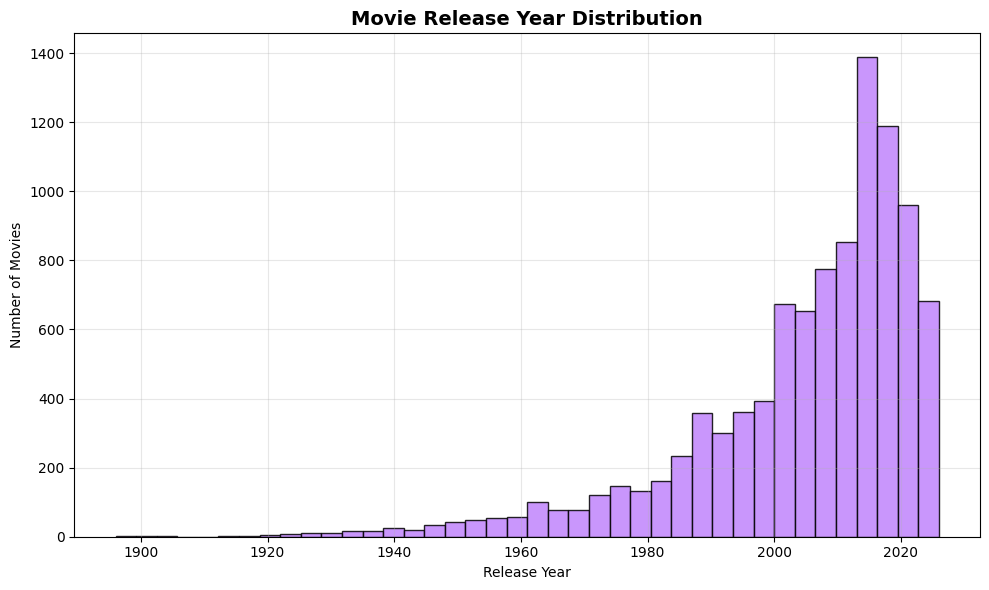

In [17]:
# ================================
# 5. Release Year Distribution
# ================================
plt.figure(figsize=(10,6))

release_year = pd.to_datetime(
    df['release_date'],
    errors='coerce'
).dt.year.dropna()

plt.hist(
    release_year,
    bins=40,
    color='#c084fc',
    edgecolor='black',
    alpha=0.85
)

plt.title("Movie Release Year Distribution", fontsize=14, fontweight='bold')
plt.xlabel("Release Year")
plt.ylabel("Number of Movies")
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

#### **Analysis: Movie Release Year Distribution**

This histogram visualizes the distribution of movie release years. The distribution shows a clear upward trend over time, with a significant increase in the number of movies released in recent decades. This likely reflects the growth of the film industry and the increasing volume of movie production. It's important to consider that older movies might be over-represented in 'top-rated' lists if they have stood the test of time, while newer movies might have fewer votes but still qualify as 'top-rated' due to early critical acclaim or high initial popularity.

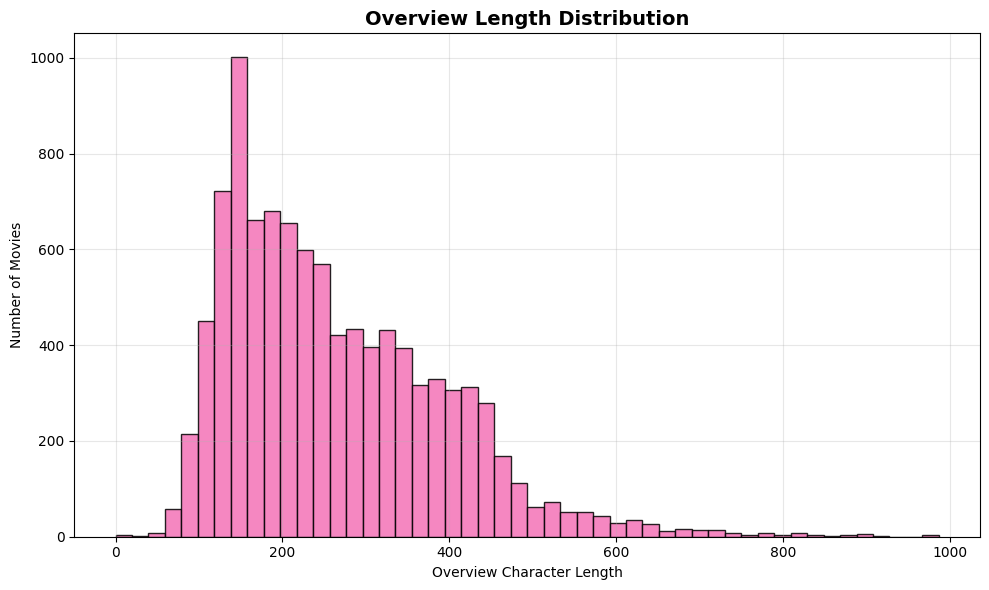

In [19]:
# ================================
# 6. Overview Length Distribution
# ================================

plt.figure(figsize=(10,6))

overview_length = df['overview'].fillna('').apply(len)

plt.hist(
    overview_length,
    bins=50,
    color='#f472b6',
    edgecolor='black',
    alpha=0.85
)

plt.title("Overview Length Distribution", fontsize=14, fontweight='bold')
plt.xlabel("Overview Character Length")
plt.ylabel("Number of Movies")
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

#### **Analysis: Overview Length Distribution**

This histogram displays the distribution of the character length of movie overviews. The distribution generally appears bell-shaped, peaking around a moderate length. This suggests that most movie overviews fall within a typical descriptive range, providing sufficient detail without being overly verbose. Very short or very long overviews are less common. This feature can indirectly indicate the complexity of a movie's plot or the descriptive effort put into its synopsis, which might correlate with audience engagement or perceived quality.

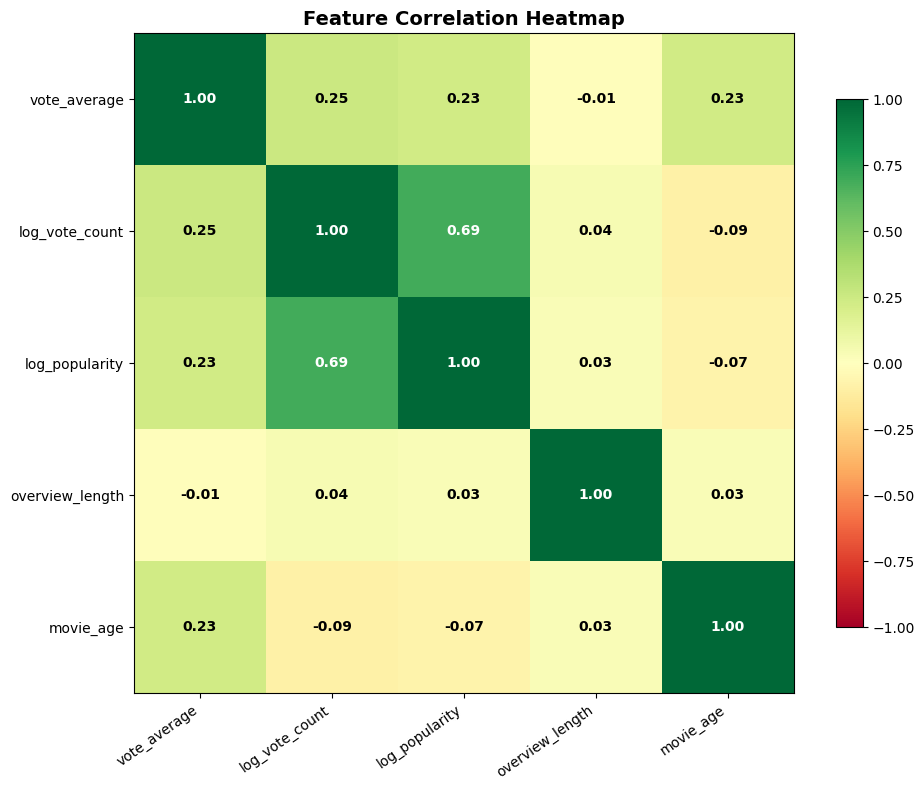

In [20]:
log_vc = np.log1p(df['vote_count'])
log_pop = np.log1p(df['popularity'])
ovl = df['overview'].fillna('').apply(len)
age = 2024 - pd.to_datetime(df['release_date'], errors='coerce').dt.year.fillna(2000)

corr_df = pd.DataFrame({
    'vote_average': df['vote_average'],
    'log_vote_count': log_vc,
    'log_popularity': log_pop,
    'overview_length': ovl,
    'movie_age': age
})

corr = corr_df.corr()

plt.figure(figsize=(10,8))

im = plt.imshow(corr, cmap='RdYlGn', vmin=-1, vmax=1)

plt.xticks(range(len(corr.columns)), corr.columns, rotation=35, ha='right')
plt.yticks(range(len(corr.columns)), corr.columns)

for i in range(len(corr)):
    for j in range(len(corr)):
        value = corr.iloc[i, j]
        plt.text(
            j, i, f"{value:.2f}",
            ha='center',
            va='center',
            fontsize=10,
            fontweight='bold',
            color='white' if abs(value) > 0.5 else 'black'
        )

plt.colorbar(im, shrink=0.8)
plt.title("Feature Correlation Heatmap", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [21]:
# ── Feature Engineering ───────────────────────────────────────────────
df['release_year']    = pd.to_datetime(df['release_date'], errors='coerce').dt.year.fillna(2000)
df['movie_age']       = 2024 - df['release_year']
top5                  = df['original_language'].value_counts().nlargest(5).index
df['lang_group']      = df['original_language'].apply(lambda x: x if x in top5 else 'other')
le                    = LabelEncoder()
df['lang_enc']        = le.fit_transform(df['lang_group'])
df['is_english']      = (df['original_language'] == 'en').astype(int)
df['log_vote_count']  = np.log1p(df['vote_count'])
df['log_popularity']  = np.log1p(df['popularity'])
df['overview_length'] = df['overview'].fillna('').apply(len)
df['word_count']      = df['overview'].fillna('').apply(lambda x: len(x.split()))
df['pop_x_votes']     = df['log_popularity'] * df['log_vote_count']
df['age_x_votes']     = df['movie_age']      * df['log_vote_count']

df['rating_tier'] = pd.cut(df['vote_average'], bins=[5.4,6.5,7.5,9.0],
                            labels=['Average','Good','Excellent'])
df = df.dropna(subset=['rating_tier'])
df['rating_tier'] = df['rating_tier'].astype(str)

FEATURES = ['log_popularity','log_vote_count','movie_age','lang_enc','is_english',
            'overview_length','word_count','pop_x_votes','age_x_votes']

print(f"Engineered shape: {df.shape}")
print(f"\nClass distribution:")
for cls, cnt in df['rating_tier'].value_counts().items():
    bar = '█' * int(cnt/len(df)*40)
    print(f"  {cls:<12} {bar:<25} {cnt:>5}  ({cnt/len(df)*100:.1f}%)")


Engineered shape: (10000, 22)

Class distribution:
  Good         ███████████████████        4807  (48.1%)
  Average      ███████████████            3889  (38.9%)
  Excellent    █████                      1304  (13.0%)


In [22]:
# Save feature engineered dataset as CSV for Model Building

df.to_csv("movie_feature_engineered.csv", index=False)

print("CSV file saved successfully!")

CSV file saved successfully!
